# Heat (Diffusion) Equation — Numerical Methods & Neural Networks

## Problem Statement

The **heat equation** (also called the **diffusion equation**) describes the spread of heat (or any diffusing quantity) over time in a spatial domain:

$$u_t = \alpha\, u_{xx}, \qquad x \in [0,1],\quad t \in [0, T]$$

where $\alpha > 0$ is the **thermal diffusivity**.

### Setup in this notebook

| Quantity | Value |
|----------|-------|
| $\alpha$ | $0.10$ |
| $T$ | $1.0$ |
| IC | $u(x,0) = \sin(\pi x) + 0.5\sin(3\pi x)$ |
| Left BC | $u(0,t) = 0$ |
| Right BC | $u(1,t) = 0$ |

### Exact (analytical) solution

Because the PDE is linear with homogeneous Dirichlet BCs, the solution is a sum of decaying Fourier modes:

$$u^*(x,t) = e^{-\alpha\pi^2 t}\sin(\pi x) + 0.5\,e^{-9\alpha\pi^2 t}\sin(3\pi x)$$

Higher modes decay much faster (by a factor $k^2$ in the exponent), which makes this problem excellent for testing the diffusive accuracy of each solver.

---

## Approaches Covered

| Part | Method | Type |
|------|--------|------|
| 1a | **FTCS** (Forward-Time Centred-Space) | Explicit finite difference |
| 1b | **Crank–Nicolson** | Implicit finite difference ($\theta$-method, $\theta=0.5$) |
| 1c | **Convergence study** | Grid refinement, order verification |
| 2 | **PINN** (Physics-Informed Neural Network) | Deep learning |
| 3 | **Comparison** | Error, efficiency, trade-offs |

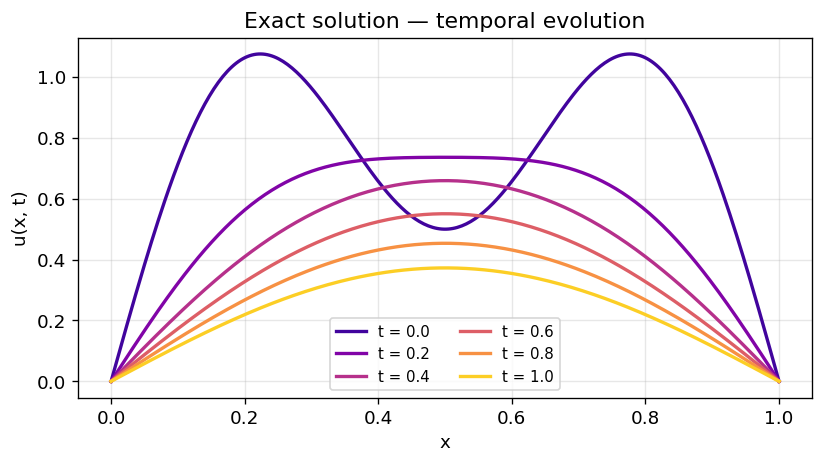

Diffusivity α = 0.1,  T = 1.0
Mode 1 decay at T: 0.3727
Mode 3 decay at T: 0.0001  (9× faster)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve

# ---- reproducibility -----------------------------------
import torch
torch.manual_seed(42)
np.random.seed(42)

# ---- global style -----------------------------------
CMAP = "inferno"
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})

# ---- problem parameters -----------------------------------
ALPHA = 0.10          # thermal diffusivity
T_END = 1.0           # final time
X_LO, X_HI = 0.0, 1.0

# ---- initial condition & exact solution -----------------------------------
def u_ic(x):
    """u(x,0) = sin(πx) + 0.5 sin(3πx)"""
    return np.sin(np.pi * x) + 0.5 * np.sin(3.0 * np.pi * x)

def u_exact(x, t, alpha=ALPHA):
    """Superposition of two decaying Fourier modes."""
    return (np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)
            + 0.5 * np.exp(-9.0 * alpha * np.pi**2 * t) * np.sin(3.0 * np.pi * x))

# ---- quick preview -----------------------------------
x_plot = np.linspace(X_LO, X_HI, 300)
t_plot = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_plot)))

fig, ax = plt.subplots(figsize=(7, 4))
for t_val, c in zip(t_plot, colors):
    ax.plot(x_plot, u_exact(x_plot, t_val), color=c, lw=2,
            label=f"t = {t_val:.1f}")
ax.set_xlabel("x")
ax.set_ylabel("u(x, t)")
ax.set_title("Exact solution — temporal evolution")
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Diffusivity α = {ALPHA},  T = {T_END}")
print(f"Mode 1 decay at T: {np.exp(-ALPHA*np.pi**2*T_END):.4f}")
print(f"Mode 3 decay at T: {np.exp(-9*ALPHA*np.pi**2*T_END):.4f}  (9× faster)")

---
## Part 1a — FTCS Explicit Finite Difference

### Discretisation

Divide the domain into $N_x$ interior points with spacing $\Delta x = 1/(N_x+1)$ and time step $\Delta t$.  
Applying a **forward difference** in time and **centred difference** in space:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \alpha\,\frac{u_{i-1}^n - 2u_i^n + u_{i+1}^n}{\Delta x^2}$$

Rearranging with the **mesh Fourier number** $r = \alpha\Delta t/\Delta x^2$:

$$\boxed{u_i^{n+1} = r\,u_{i-1}^n + (1-2r)\,u_i^n + r\,u_{i+1}^n}$$

### Stability condition

The scheme is **conditionally stable**.  The von Neumann analysis requires:

$$r = \frac{\alpha\,\Delta t}{\Delta x^2} \leq \frac{1}{2}$$

We enforce $r = 0.45$ (slightly below the limit) to choose the time step automatically.

FTCS:  Nx=100,  Nt=2267,  final L2-error = 3.5839e-05


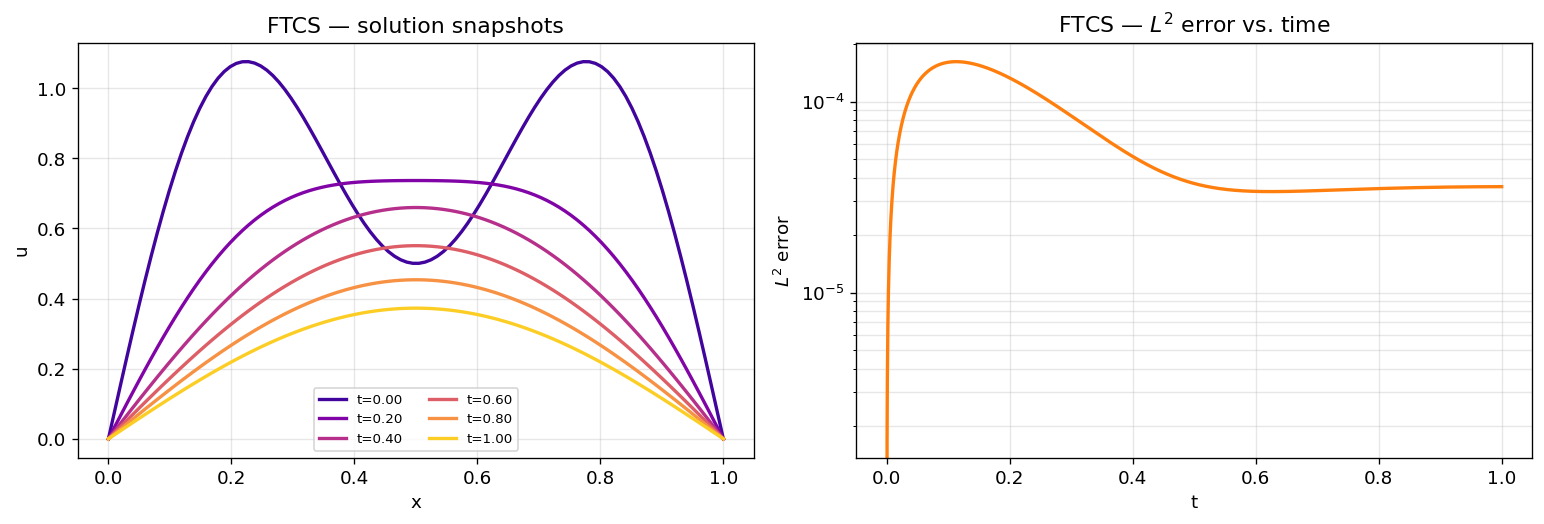

In [ ]:
def solve_ftcs(Nx=100, r=0.45, alpha=ALPHA, t_end=T_END):
    """
    FTCS explicit scheme for u_t = alpha * u_xx.

    Parameters
    ----------
    Nx : int   — number of interior grid points
    r  : float — mesh Fourier number (stability: r <= 0.5)

    Returns
    -------
    x  : (Nx,)       interior node positions
    t  : (Nt+1,)     time levels
    U  : (Nt+1, Nx)  solution snapshots
    """
    dx = 1.0 / (Nx + 1)
    dt = r * dx**2 / alpha
    t  = np.arange(0.0, t_end + dt, dt)
    Nt = len(t) - 1

    x = np.linspace(dx, 1.0 - dx, Nx)   # interior nodes only
    U = np.zeros((Nt + 1, Nx))
    U[0] = u_ic(x)

    for n in range(Nt):
        u   = U[n]
        ul  = np.roll(u,  1);  ul[0]  = 0.0   # left BC
        ur  = np.roll(u, -1);  ur[-1] = 0.0   # right BC
        U[n+1] = u + r * (ul - 2*u + ur)

    return x, t, U


# ---- run & report -----------------------------------─
x_ftcs, t_ftcs, U_ftcs = solve_ftcs(Nx=100, r=0.45)
u_ref  = np.array([u_exact(x_ftcs, ti) for ti in t_ftcs])
l2_err = np.sqrt(np.mean((U_ftcs - u_ref)**2, axis=1))

print(f"FTCS:  Nx={len(x_ftcs)},  Nt={len(t_ftcs)-1},  "
      f"final L2-error = {l2_err[-1]:.4e}")

# ---- snapshots -------------------------------------------
snap_times = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
snap_idx   = [np.argmin(np.abs(t_ftcs - ts)) for ts in snap_times]
colors     = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_times)))
x_full     = np.concatenate([[0.0], x_ftcs, [1.0]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for idx, c in zip(snap_idx, colors):
    u_plot = np.concatenate([[0.0], U_ftcs[idx], [0.0]])
    ax.plot(x_full, u_plot, color=c, lw=2, label=f"t={t_ftcs[idx]:.2f}")
ax.set_title("FTCS — solution snapshots")
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(t_ftcs, l2_err, "C1", lw=2)
ax.set_title("FTCS — $L^2$ error vs. time")
ax.set_xlabel("t"); ax.set_ylabel("$L^2$ error")
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

---
## Part 1b — Crank–Nicolson Implicit Scheme

### Discretisation ($\theta$-method with $\theta = 0.5$)

The **Crank–Nicolson** scheme averages the spatial operator at levels $n$ and $n+1$:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \frac{\alpha}{2}
  \left(\delta^2_x u_i^n + \delta^2_x u_i^{n+1}\right)$$

where $\delta^2_x u_i = (u_{i-1} - 2u_i + u_{i+1})/\Delta x^2$.  
Rearranging with $r = \alpha\Delta t/\Delta x^2$:

$$-\tfrac{r}{2}\,u_{i-1}^{n+1} + (1+r)\,u_i^{n+1} - \tfrac{r}{2}\,u_{i+1}^{n+1}
= \tfrac{r}{2}\,u_{i-1}^n + (1-r)\,u_i^n + \tfrac{r}{2}\,u_{i+1}^n$$

This is a **tridiagonal linear system** solved at each time step with `scipy.sparse.linalg.spsolve`.

### Properties

| Property | FTCS | Crank–Nicolson |
|----------|------|----------------|
| Stability | Conditional ($r\leq 0.5$) | **Unconditional** |
| Temporal order | $\mathcal{O}(\Delta t)$ | $\mathcal{O}(\Delta t^2)$ |
| Spatial order | $\mathcal{O}(\Delta x^2)$ | $\mathcal{O}(\Delta x^2)$ |
| Cost per step | $\mathcal{O}(N)$ | $\mathcal{O}(N)$ (banded solve) |

CN:  Nx=100,  Nt=200,  r=5.100,  final L2-error = 2.0547e-05


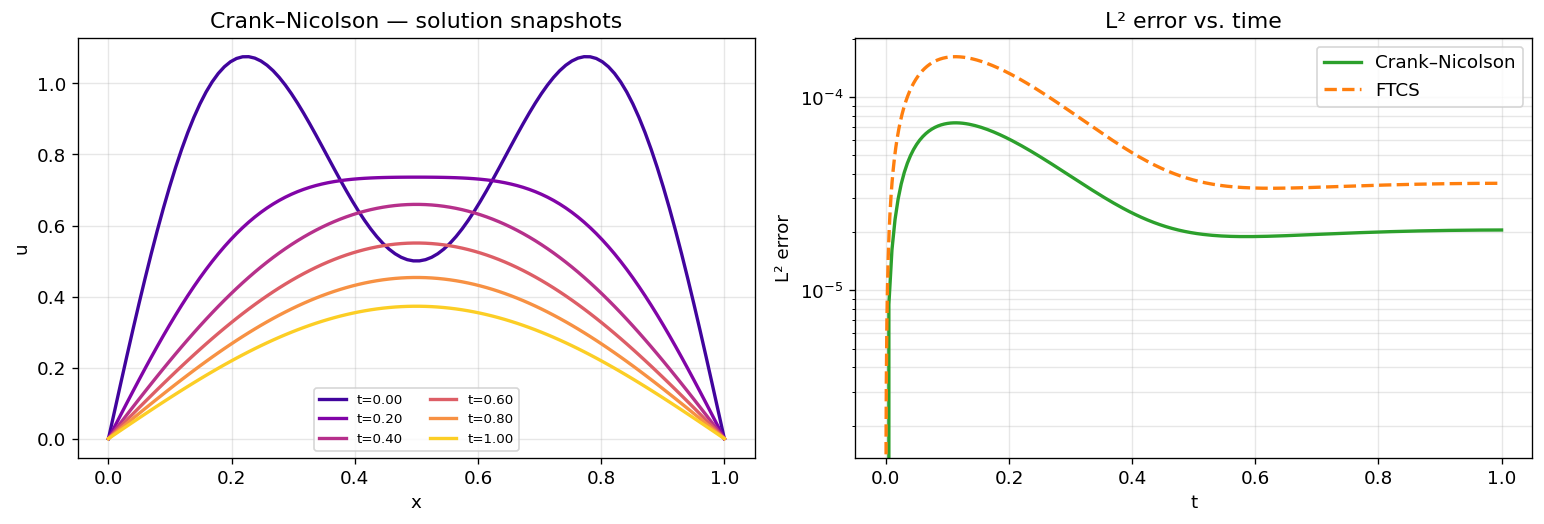

In [4]:
def solve_crank_nicolson(Nx=100, Nt=200, alpha=ALPHA, t_end=T_END):
    """
    Crank-Nicolson implicit scheme for u_t = alpha * u_xx.

    Parameters
    ----------
    Nx : int — number of interior grid points
    Nt : int — number of time steps

    Returns
    -------
    x  : (Nx,)       interior node positions
    t  : (Nt+1,)     time levels
    U  : (Nt+1, Nx)  solution snapshots
    """
    dx = 1.0 / (Nx + 1)
    dt = t_end / Nt
    r  = alpha * dt / dx**2

    x = np.linspace(dx, 1.0 - dx, Nx)
    t = np.linspace(0.0, t_end, Nt + 1)

    # Build tridiagonal matrices (interior DOFs only, BCs are zero → no RHS correction)
    main_d  = np.full(Nx,  1.0 + r)
    off_d   = np.full(Nx - 1, -r / 2.0)
    A = diags([off_d, main_d, off_d], [-1, 0, 1], format="csr")   # LHS

    rhs_main = np.full(Nx,  1.0 - r)
    rhs_off  = np.full(Nx - 1,  r / 2.0)
    B = diags([rhs_off, rhs_main, rhs_off], [-1, 0, 1], format="csr")  # RHS matrix

    U    = np.zeros((Nt + 1, Nx))
    U[0] = u_ic(x)

    for n in range(Nt):
        rhs    = B @ U[n]   # BCs contribute 0 (homogeneous Dirichlet)
        U[n+1] = spsolve(A, rhs)

    return x, t, U


# ---- run & report -----------------------------------─
x_cn, t_cn, U_cn = solve_crank_nicolson(Nx=100, Nt=200)
u_ref_cn = np.array([u_exact(x_cn, ti) for ti in t_cn])
l2_err_cn = np.sqrt(np.mean((U_cn - u_ref_cn)**2, axis=1))

print(f"CN:  Nx={len(x_cn)},  Nt={len(t_cn)-1},  "
      f"r={ALPHA*(T_END/200)/(1/101)**2:.3f},  "
      f"final L2-error = {l2_err_cn[-1]:.4e}")

# ---- snapshots -------------------------------------------
snap_times = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
snap_idx   = [np.argmin(np.abs(t_cn - ts)) for ts in snap_times]
x_full_cn  = np.concatenate([[0.0], x_cn, [1.0]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for idx, c in zip(snap_idx, plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_times)))):
    u_plot = np.concatenate([[0.0], U_cn[idx], [0.0]])
    ax.plot(x_full_cn, u_plot, color=c, lw=2, label=f"t={t_cn[idx]:.2f}")
ax.set_title("Crank–Nicolson — solution snapshots")
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(t_cn, l2_err_cn, "C2", lw=2, label="Crank–Nicolson")
ax.semilogy(t_ftcs, l2_err,  "C1", lw=2, linestyle="--", label="FTCS")
ax.set_title("L² error vs. time"); ax.set_xlabel("t"); ax.set_ylabel("L² error")
ax.legend(); ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

---
## Part 1c — Grid Convergence Study

We measure the **global $L^\infty$ error** at $t = T_{\text{end}}$ while simultaneously refining $\Delta x$ and $\Delta t$:

- **FTCS**: keep $r = 0.45$ fixed so $\Delta t \propto \Delta x^2$ → error $\mathcal{O}(\Delta x^2 + \Delta t) = \mathcal{O}(\Delta x^2)$  
  *(but since $\Delta t = r\Delta x^2/\alpha$, both contributions are $\mathcal{O}(\Delta x^2)$)*
- **Crank–Nicolson**: set $\Delta t = \Delta x$ → error $\mathcal{O}(\Delta x^2 + \Delta t^2) = \mathcal{O}(\Delta x^2)$

Expected slopes on a log–log plot: **−2** for both methods.

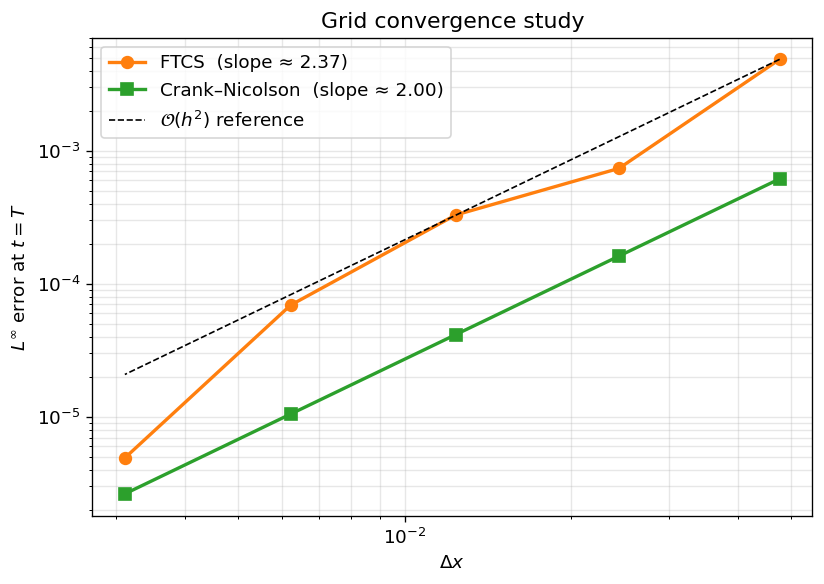


Convergence table
    Nx          Δx      FTCS error        CN error
    20      0.0476      4.8712e-03      6.1567e-04
    40      0.0244      7.3794e-04      1.6181e-04
    80      0.0123      3.2897e-04      4.1477e-05
   160      0.0062      6.9124e-05      1.0500e-05
   320      0.0031      4.9162e-06      2.6414e-06

Observed order — FTCS: 2.37,  CN: 2.00


In [5]:
Nx_levels = [20, 40, 80, 160, 320]
dx_vals   = []
err_ftcs  = []
err_cn    = []

for Nx in Nx_levels:
    dx = 1.0 / (Nx + 1)
    dx_vals.append(dx)

    # FTCS: r = 0.45 fixed
    _, t_f, U_f = solve_ftcs(Nx=Nx, r=0.45)
    x_f = np.linspace(dx, 1.0 - dx, Nx)
    err_ftcs.append(np.max(np.abs(U_f[-1] - u_exact(x_f, T_END))))

    # CN: Nt chosen so Δt ≈ Δx
    Nt_cn = max(10, int(round(T_END / dx)))
    _, t_c, U_c = solve_crank_nicolson(Nx=Nx, Nt=Nt_cn)
    x_c = np.linspace(dx, 1.0 - dx, Nx)
    err_cn.append(np.max(np.abs(U_c[-1] - u_exact(x_c, T_END))))

dx_arr   = np.array(dx_vals)
err_ftcs = np.array(err_ftcs)
err_cn   = np.array(err_cn)

# ---- fitted slopes -----------------------------------
slope_ftcs = np.polyfit(np.log(dx_arr), np.log(err_ftcs), 1)[0]
slope_cn   = np.polyfit(np.log(dx_arr), np.log(err_cn),   1)[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dx_arr, err_ftcs, "C1o-", lw=2, ms=7,
          label=f"FTCS  (slope ≈ {slope_ftcs:.2f})")
ax.loglog(dx_arr, err_cn,   "C2s-", lw=2, ms=7,
          label=f"Crank–Nicolson  (slope ≈ {slope_cn:.2f})")
# reference O(h^2) line
ref = err_ftcs[0] * (dx_arr / dx_arr[0])**2
ax.loglog(dx_arr, ref, "k--", lw=1, label="$\\mathcal{O}(h^2)$ reference")
ax.set_xlabel("$\\Delta x$"); ax.set_ylabel("$L^\\infty$ error at $t=T$")
ax.set_title("Grid convergence study")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("\nConvergence table")
print(f"{'Nx':>6}  {'Δx':>10}  {'FTCS error':>14}  {'CN error':>14}")
for i, Nx in enumerate(Nx_levels):
    print(f"{Nx:>6}  {dx_vals[i]:>10.4f}  {err_ftcs[i]:>14.4e}  {err_cn[i]:>14.4e}")
print(f"\nObserved order — FTCS: {slope_ftcs:.2f},  CN: {slope_cn:.2f}")

---
## Part 2 — Physics-Informed Neural Network (PINN)

### Idea

A PINN approximates the solution as a neural network $u_\theta(x, t)$ and trains it by minimising a composite loss that penalises violations of:

1. **PDE residual** (interior collocation points):

$$\mathcal{L}_{\text{PDE}} = \frac{1}{N_f}\sum_{i=1}^{N_f}
   \left(\frac{\partial u_\theta}{\partial t}\bigg|_{(x_i,t_i)}
   - \alpha\,\frac{\partial^2 u_\theta}{\partial x^2}\bigg|_{(x_i,t_i)}\right)^2$$

2. **Initial condition**:

$$\mathcal{L}_{\text{IC}} = \frac{1}{N_0}\sum_{i=1}^{N_0}
   \left(u_\theta(x_i, 0) - u_0(x_i)\right)^2$$

3. **Boundary conditions** (left + right walls at all times):

$$\mathcal{L}_{\text{BC}} = \frac{1}{N_b}\sum_{i=1}^{N_b}
   \left[u_\theta(0, t_i)^2 + u_\theta(1, t_i)^2\right]$$

$$\mathcal{L} = \mathcal{L}_{\text{PDE}} + \lambda_{\text{IC}}\,\mathcal{L}_{\text{IC}} + \lambda_{\text{BC}}\,\mathcal{L}_{\text{BC}}$$

### Architecture

- 5 fully-connected hidden layers, 64 neurons each, **Tanh** activation
- `torch.autograd.grad` for $\partial u/\partial t$ and $\partial^2 u/\partial x^2$
- Two-phase training: **Adam** (fast warm-up) → **L-BFGS** (fine-tuning)

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---- helper: first-order derivative -------------------------------------------
def grad1(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]

# ---- PINN architecture -----------------------------------─
class HeatPINN(nn.Module):
    def __init__(self, hidden=64, layers=5):
        super().__init__()
        acts  = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(layers - 1):
            acts += [nn.Linear(hidden, hidden), nn.Tanh()]
        acts  += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*acts)

        # Xavier / Glorot initialisation — safer for deep Tanh nets
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)


# ---- collocation point samplers ---------------------------------------------------─
def sample_interior(N=10_000):
    x = torch.rand(N, 1, device=device, requires_grad=True)
    t = torch.rand(N, 1, device=device, requires_grad=True) * T_END
    return x, t

def sample_ic(N=2_000):
    x   = torch.rand(N, 1, device=device, requires_grad=True)
    t   = torch.zeros(N, 1, device=device, requires_grad=True)
    u0  = (torch.sin(torch.pi * x) + 0.5 * torch.sin(3.0 * torch.pi * x)).detach()
    return x, t, u0

def sample_bc(N=2_000):
    t   = torch.rand(N, 1, device=device, requires_grad=True) * T_END
    x0  = torch.zeros(N, 1, device=device, requires_grad=True)
    x1  = torch.ones( N, 1, device=device, requires_grad=True)
    return x0, x1, t


model = HeatPINN(hidden=64, layers=5).to(device)
params = sum(p.numel() for p in model.parameters())
print(f"PINN parameters: {params:,}")

Using device: cpu
PINN parameters: 16,897


In [7]:
ALPHA_T  = torch.tensor(ALPHA, dtype=torch.float32, device=device)
LAM_IC   = 10.0    # IC weight
LAM_BC   = 10.0    # BC weight

def compute_loss(model):
    # ---- PDE residual -----------------------------------
    xf, tf  = sample_interior(10_000)
    u_pred  = model(xf, tf)
    u_t     = grad1(u_pred, tf)
    u_x     = grad1(u_pred, xf)
    u_xx    = grad1(u_x, xf)
    pde_res = u_t - ALPHA_T * u_xx
    loss_pde = torch.mean(pde_res**2)

    # ---- initial condition ---------------------------------------------------------------
    xi, ti, u0 = sample_ic(2_000)
    loss_ic  = torch.mean((model(xi, ti) - u0)**2)

    # ---- boundary conditions -----------------------------------------------------------
    x0, x1, tb = sample_bc(2_000)
    loss_bc  = torch.mean(model(x0, tb)**2) + torch.mean(model(x1, tb)**2)

    loss = loss_pde + LAM_IC * loss_ic + LAM_BC * loss_bc
    return loss, loss_pde, loss_ic, loss_bc


# ---- Adam training -----------------------------------
N_ADAM   = 5_000
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler      = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=2000, gamma=0.5)

history = {"total": [], "pde": [], "ic": [], "bc": []}

for epoch in range(1, N_ADAM + 1):
    optimizer_adam.zero_grad()
    loss, lp, li, lb = compute_loss(model)
    loss.backward()
    optimizer_adam.step()
    scheduler.step()

    if epoch % 500 == 0 or epoch == 1:
        history["total"].append(loss.item())
        history["pde"].append(lp.item())
        history["ic"].append(li.item())
        history["bc"].append(lb.item())
        print(f"Adam [{epoch:5d}/{N_ADAM}]  total={loss.item():.4e}  "
              f"pde={lp.item():.4e}  ic={li.item():.4e}  bc={lb.item():.4e}")

Adam [    1/5000]  total=5.7708e+00  pde=2.0388e-02  ic=5.6641e-01  bc=8.6331e-03
Adam [  500/5000]  total=8.3574e-01  pde=6.8718e-02  ic=6.9826e-02  bc=6.8765e-03
Adam [ 1000/5000]  total=1.4193e-02  pde=6.7518e-03  ic=3.5332e-04  bc=3.9083e-04
Adam [ 1500/5000]  total=4.7715e-02  pde=3.1030e-03  ic=2.0516e-03  bc=2.4096e-03
Adam [ 2000/5000]  total=2.5679e-03  pde=1.2776e-03  ic=6.5794e-05  bc=6.3238e-05
Adam [ 2500/5000]  total=1.3377e-03  pde=9.9770e-04  ic=2.4232e-05  bc=9.7709e-06
Adam [ 3000/5000]  total=8.8753e-04  pde=6.6068e-04  ic=1.5731e-05  bc=6.9534e-06
Adam [ 3500/5000]  total=7.3739e-04  pde=5.6896e-04  ic=9.7598e-06  bc=7.0831e-06
Adam [ 4000/5000]  total=6.4117e-04  pde=3.9181e-04  ic=1.1703e-05  bc=1.3234e-05
Adam [ 4500/5000]  total=4.5830e-04  pde=3.6655e-04  ic=5.5760e-06  bc=3.5989e-06
Adam [ 5000/5000]  total=4.0516e-04  pde=3.1354e-04  ic=5.1782e-06  bc=3.9838e-06



L-BFGS final loss: 3.9685e-04


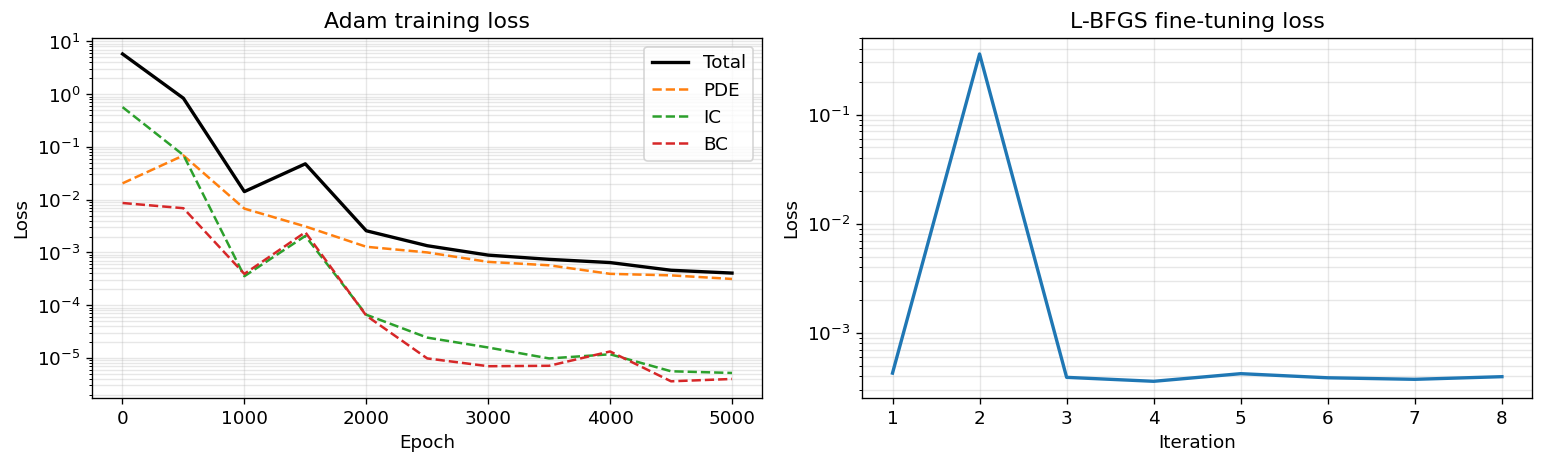

In [8]:
# ---- L-BFGS fine-tuning -----------------------------------
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    history_size=50,
    line_search_fn="strong_wolfe",
)

lbfgs_iter = [0]
lbfgs_loss = []

def closure():
    optimizer_lbfgs.zero_grad()
    loss, _, _, _ = compute_loss(model)
    loss.backward()
    lbfgs_iter[0] += 1
    lbfgs_loss.append(loss.item())
    if lbfgs_iter[0] % 100 == 0:
        print(f"L-BFGS [{lbfgs_iter[0]:4d}]  loss={loss.item():.4e}")
    return loss

optimizer_lbfgs.step(closure)
print(f"\nL-BFGS final loss: {lbfgs_loss[-1]:.4e}")

# ---- training loss curves ---------------------------------------------------------------─
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

adam_epochs = np.array([1, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000])
ax = axes[0]
ax.semilogy(adam_epochs[:len(history["total"])], history["total"], "k-",  lw=2, label="Total")
ax.semilogy(adam_epochs[:len(history["pde"])],   history["pde"],   "C1--", lw=1.5, label="PDE")
ax.semilogy(adam_epochs[:len(history["ic"])],    history["ic"],    "C2--", lw=1.5, label="IC")
ax.semilogy(adam_epochs[:len(history["bc"])],    history["bc"],    "C3--", lw=1.5, label="BC")
ax.set_title("Adam training loss"); ax.set_xlabel("Epoch")
ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3, which="both")

ax = axes[1]
ax.semilogy(np.arange(1, len(lbfgs_loss)+1), lbfgs_loss, "C0", lw=2)
ax.set_title("L-BFGS fine-tuning loss"); ax.set_xlabel("Iteration")
ax.set_ylabel("Loss"); ax.grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

PINN  max absolute error: 7.1497e-03
PINN  L2 error at t=T:    7.8417e-04


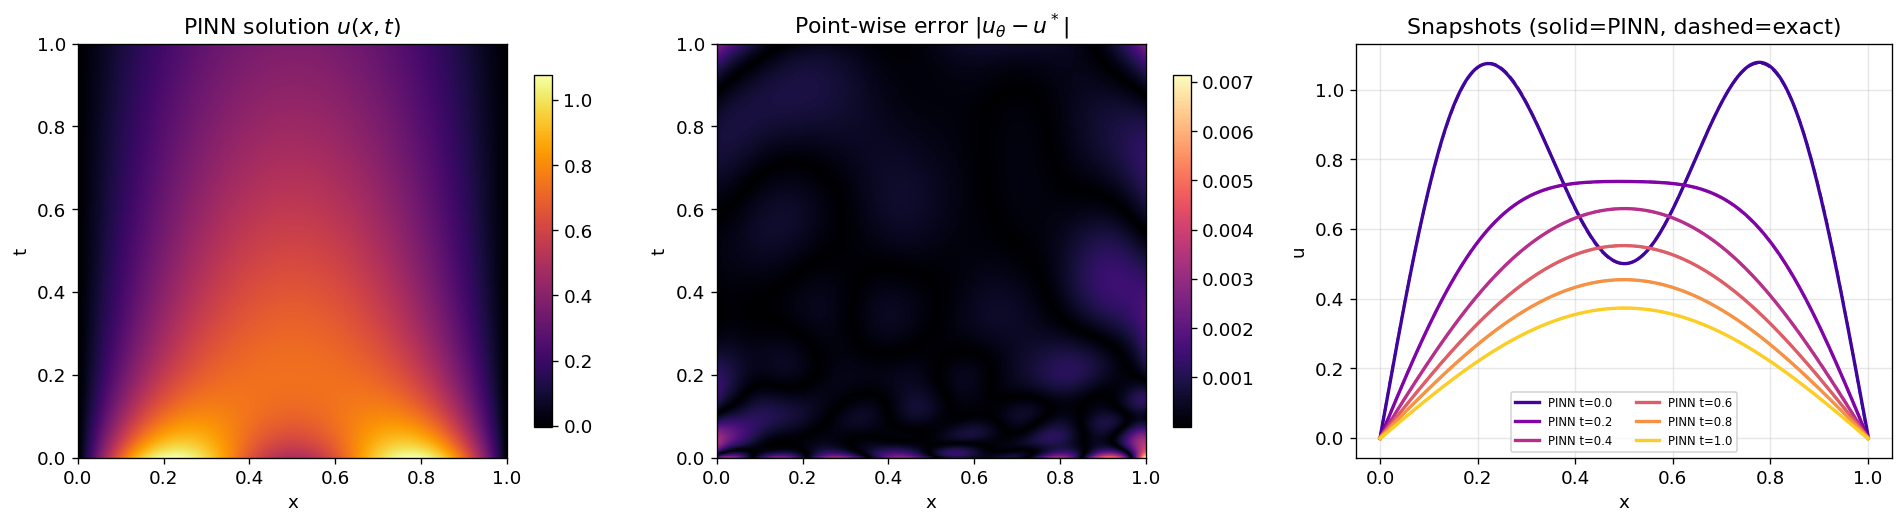

In [9]:
# ---- PINN evaluation -----------------------------------─
model.eval()

Nx_vis = 200
Nt_vis = 200
x_vis  = np.linspace(0.0, 1.0, Nx_vis)
t_vis  = np.linspace(0.0, T_END, Nt_vis)
XX, TT = np.meshgrid(x_vis, t_vis)

with torch.no_grad():
    x_t = torch.tensor(XX.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
    t_t = torch.tensor(TT.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
    u_pinn_vis = model(x_t, t_t).cpu().numpy().reshape(Nt_vis, Nx_vis)

u_exact_vis = u_exact(XX, TT)
err_pinn_vis = np.abs(u_pinn_vis - u_exact_vis)

print(f"PINN  max absolute error: {err_pinn_vis.max():.4e}")
print(f"PINN  L2 error at t=T:    "
      f"{np.sqrt(np.mean((u_pinn_vis[-1] - u_exact_vis[-1])**2)):.4e}")

# ---- PINN snapshots ---------------------------------------
snap_times = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
snap_idx_v = [np.argmin(np.abs(t_vis - ts)) for ts in snap_times]
colors_v   = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_times)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# space-time heatmap — PINN
ax = axes[0]
im = ax.imshow(u_pinn_vis, origin="lower", aspect="auto", cmap=CMAP,
               extent=[0, 1, 0, T_END])
plt.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("PINN solution $u(x,t)$")
ax.set_xlabel("x"); ax.set_ylabel("t")

# space-time heatmap — point-wise error
ax = axes[1]
im2 = ax.imshow(err_pinn_vis, origin="lower", aspect="auto", cmap="magma",
                extent=[0, 1, 0, T_END])
plt.colorbar(im2, ax=ax, shrink=0.85)
ax.set_title("Point-wise error $|u_\\theta - u^*|$")
ax.set_xlabel("x"); ax.set_ylabel("t")

# snapshots
ax = axes[2]
for idx, c in zip(snap_idx_v, colors_v):
    ax.plot(x_vis, u_pinn_vis[idx], color=c, lw=2,    label=f"PINN t={t_vis[idx]:.1f}")
    ax.plot(x_vis, u_exact_vis[idx], color=c, lw=1.5,  ls="--")
ax.set_title("Snapshots (solid=PINN, dashed=exact)")
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## Part 3 — Side-by-Side Comparison

We compare all three methods at the same spatial resolution ($N_x = 100$) over the full time interval $[0, T]$.

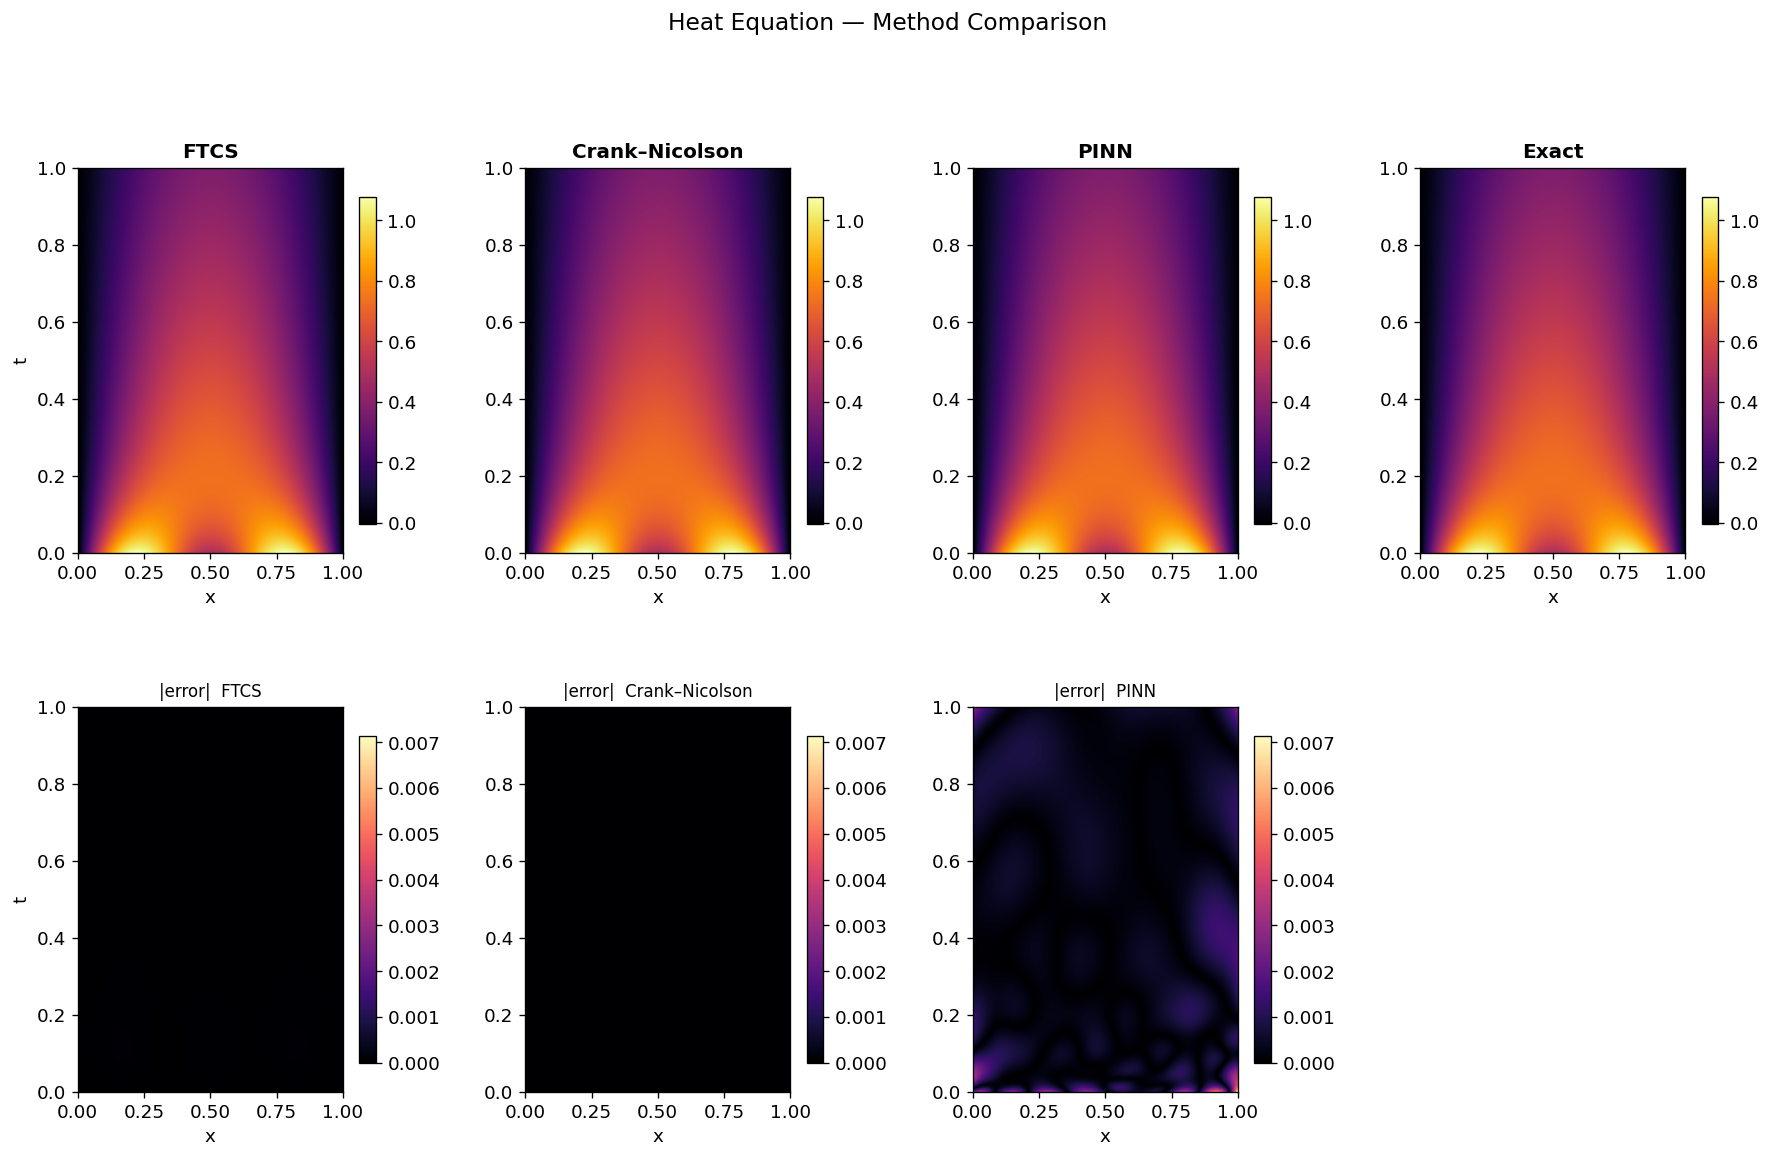

L² error at t=T
  FTCS                : 9.1618e-06
  Crank–Nicolson      : 4.8621e-06
  PINN                : 7.8417e-04


In [10]:
# ---- interpolate FD solutions onto the uniform 200-pt vis grid --------------------------------─
from scipy.interpolate import RegularGridInterpolator

# FTCS on fine grid
x_f100, t_f100, U_f100 = solve_ftcs(Nx=Nx_vis - 2, r=0.45)
x_f100_full = np.concatenate([[0.0], x_f100, [1.0]])
U_f100_full = np.hstack([np.zeros((U_f100.shape[0], 1)),
                          U_f100,
                          np.zeros((U_f100.shape[0], 1))])
interp_ftcs = RegularGridInterpolator(
    (t_f100, x_f100_full), U_f100_full, method="linear", bounds_error=False, fill_value=None)
U_ftcs_vis  = interp_ftcs(np.column_stack([TT.ravel(), XX.ravel()])).reshape(Nt_vis, Nx_vis)

# Crank-Nicolson on fine grid
x_c100, t_c100, U_c100 = solve_crank_nicolson(Nx=Nx_vis - 2, Nt=Nt_vis)
x_c100_full = np.concatenate([[0.0], x_c100, [1.0]])
U_c100_full = np.hstack([np.zeros((U_c100.shape[0], 1)),
                          U_c100,
                          np.zeros((U_c100.shape[0], 1))])
interp_cn   = RegularGridInterpolator(
    (t_c100, x_c100_full), U_c100_full, method="linear", bounds_error=False, fill_value=None)
U_cn_vis    = interp_cn(np.column_stack([TT.ravel(), XX.ravel()])).reshape(Nt_vis, Nx_vis)

# Errors relative to exact
err_ftcs_vis = np.abs(U_ftcs_vis - u_exact_vis)
err_cn_vis   = np.abs(U_cn_vis   - u_exact_vis)

# ---- 4-row comparison figure -----------------------------------------------------------
methods  = ["FTCS", "Crank–Nicolson", "PINN",   "Exact"]
sol_maps = [U_ftcs_vis, U_cn_vis,     u_pinn_vis, u_exact_vis]
err_maps = [err_ftcs_vis, err_cn_vis, err_pinn_vis, None]

vmin = min(s.min() for s in sol_maps)
vmax = max(s.max() for s in sol_maps)
emax = max(e.max() for e in err_maps if e is not None)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, hspace=0.40, wspace=0.35)

for col, (name, sol, err) in enumerate(zip(methods, sol_maps, err_maps)):
    # top row — solution
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(sol, origin="lower", aspect="auto", cmap=CMAP,
                   extent=[0, 1, 0, T_END], vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("x"); ax.set_ylabel("t" if col == 0 else "")

    # bottom row — error (skip exact)
    ax2 = fig.add_subplot(gs[1, col])
    if err is not None:
        im2 = ax2.imshow(err, origin="lower", aspect="auto", cmap="magma",
                         extent=[0, 1, 0, T_END], vmin=0, vmax=emax)
        plt.colorbar(im2, ax=ax2, shrink=0.85)
        ax2.set_title(f"|error|  {name}", fontsize=10)
    else:
        ax2.axis("off")
    ax2.set_xlabel("x" if err is not None else "")
    if col == 0:
        ax2.set_ylabel("t")

plt.suptitle("Heat Equation — Method Comparison", fontsize=14, y=1.01)
plt.show()

# ---- L² error at t=T -----------------------------------─
print("L² error at t=T")
for name, sol in zip(methods[:3], [U_ftcs_vis[-1], U_cn_vis[-1], u_pinn_vis[-1]]):
    l2 = np.sqrt(np.mean((sol - u_exact_vis[-1])**2))
    print(f"  {name:<20s}: {l2:.4e}")

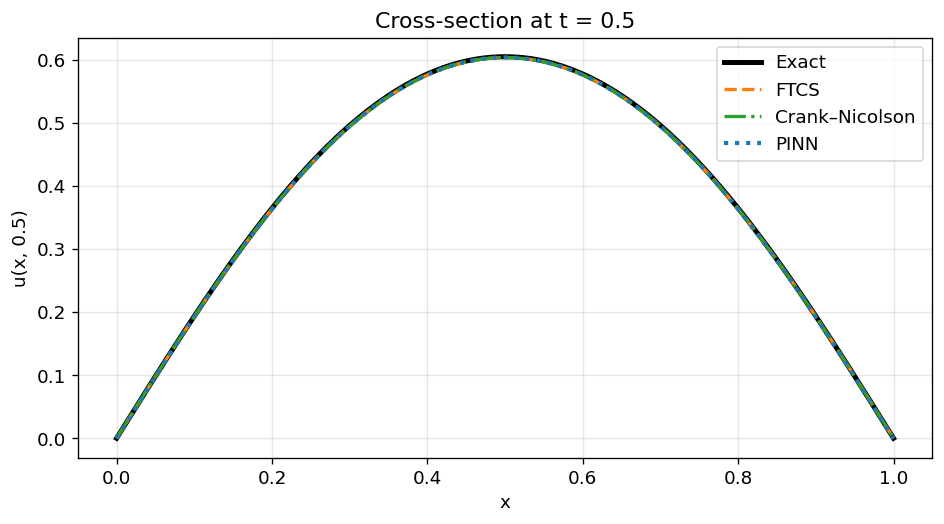

In [11]:
# ---- cross-section at t = 0.5 -------------------------------------------------------─
t_cross = 0.5
idx_f = np.argmin(np.abs(t_vis - t_cross))
u_ex_cross = u_exact(x_vis, t_cross)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_vis, u_ex_cross,         "k-",  lw=3,   label="Exact")
ax.plot(x_vis, U_ftcs_vis[idx_f],  "C1--", lw=2,  label="FTCS")
ax.plot(x_vis, U_cn_vis[idx_f],    "C2-.", lw=2,  label="Crank–Nicolson")
ax.plot(x_vis, u_pinn_vis[idx_f],  "C0:",  lw=2.5, label="PINN")
ax.set_xlabel("x"); ax.set_ylabel(f"u(x, {t_cross})")
ax.set_title(f"Cross-section at t = {t_cross}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()